## ASSIGNMENT 6: Seaborn Advanced Visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('assignment6_customer_analytics(in).csv')
df

,CustomerID,Age,Income,PurchaseCount,AvgOrderValue,Region,Category,CustomerRating,YearsAsCustomer
0,2001,44,111365,23,1000,East,Software,3.2,1
1,2002,25,139014,45,3184,West,Software,3.6,7
2,2003,42,185806,2,2109,East,Electronics,4.4,13
3,2004,63,97588,41,341,South,Accessories,3.6,5
4,2005,21,88646,21,2485,East,Software,3.8,13
...,...,...,...,...,...,...,...,...,...
145,2146,35,34715,38,2681,West,Electronics,4.7,3
146,2147,19,44169,15,3968,South,Electronics,4.0,5
147,2148,66,143413,21,3637,South,Electronics,4.6,11
148,2149,30,172235,10,4965,South,Electronics,2.0,12


## Q6.1: Histogram with KDE

#### Create a histogram with KDE showing the distribution of customer ages using Seaborn

In [4]:
sns.set_style('darkgrid')

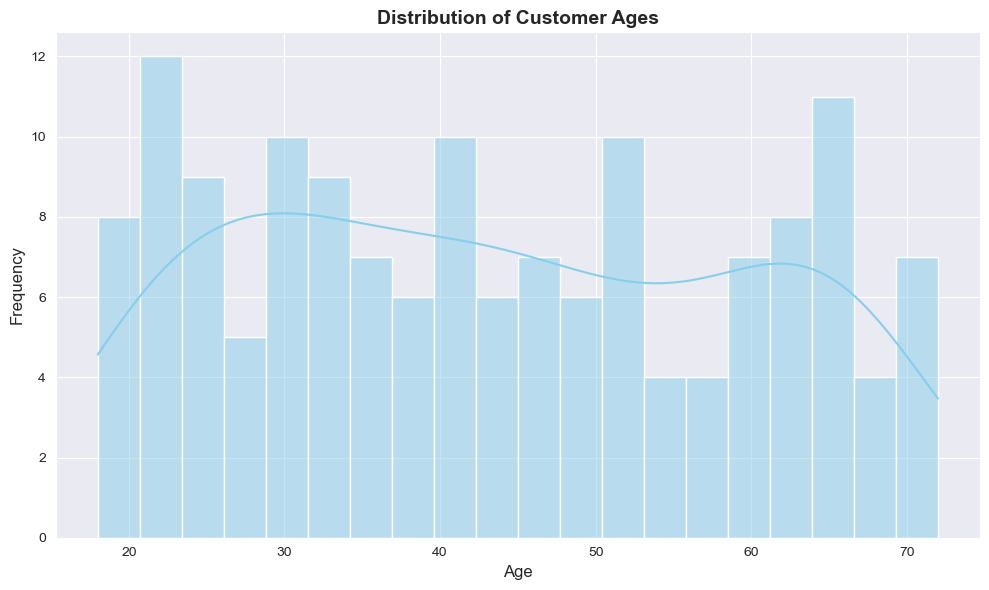

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='Age',kde=True,bins=20,color='skyblue')
plt.xlabel('Age',fontsize=12)
plt.ylabel('Frequency',fontsize=12)
plt.title('Distribution of Customer Ages',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.2: Count Plot

#### Create a count plot showing the number of customers per region

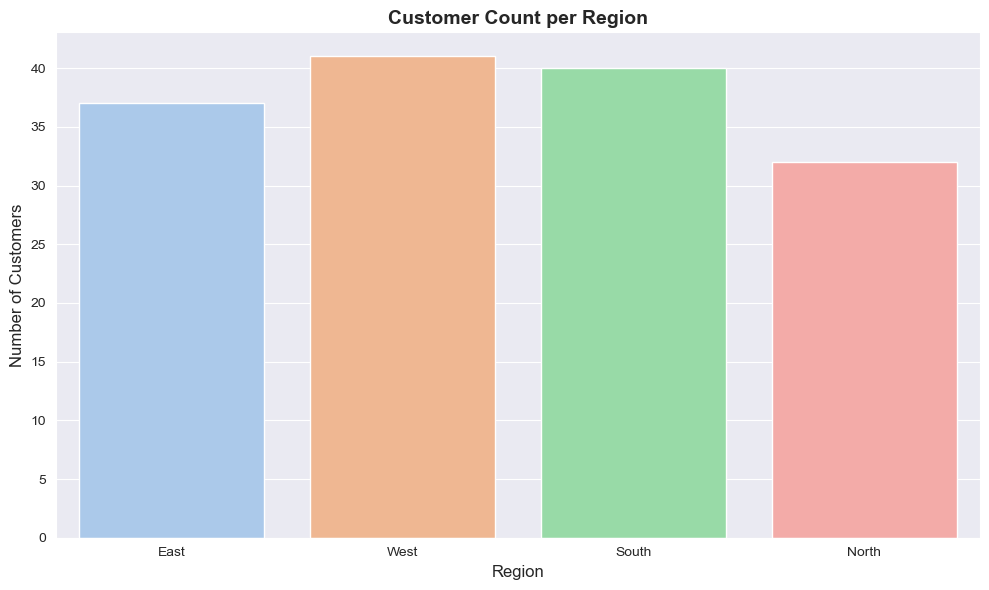

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Region',hue='Region',palette='pastel')
plt.xlabel('Region',fontsize=12)
plt.ylabel('Number of Customers',fontsize=12)
plt.title('Customer Count per Region',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.3: Scatter Plot with Hue
#### Create a scatter plot with Age vs Income, colored by Region using Seaborn

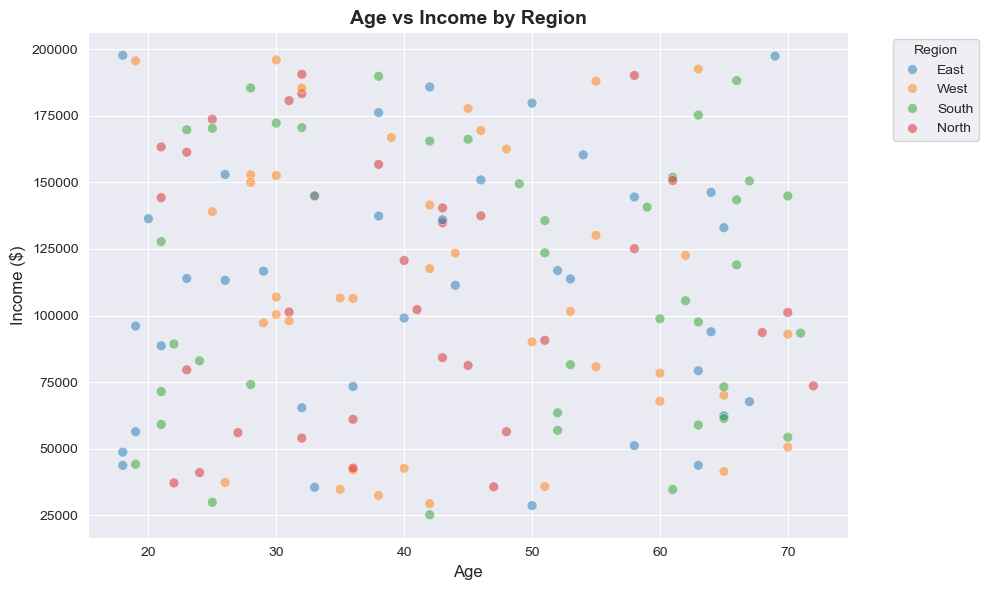

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Age',y='Income',hue='Region',s=50,alpha=0.5)
plt.xlabel('Age',fontsize=12)
plt.ylabel('Income ($)',fontsize=12)
plt.title('Age vs Income by Region',fontsize=14,fontweight='bold')
plt.legend(loc='upper left',fontsize=10,title='Region',bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

## Q6.4: Box Plot
#### Create a box plot showing the distribution of PurchaseCount across regions

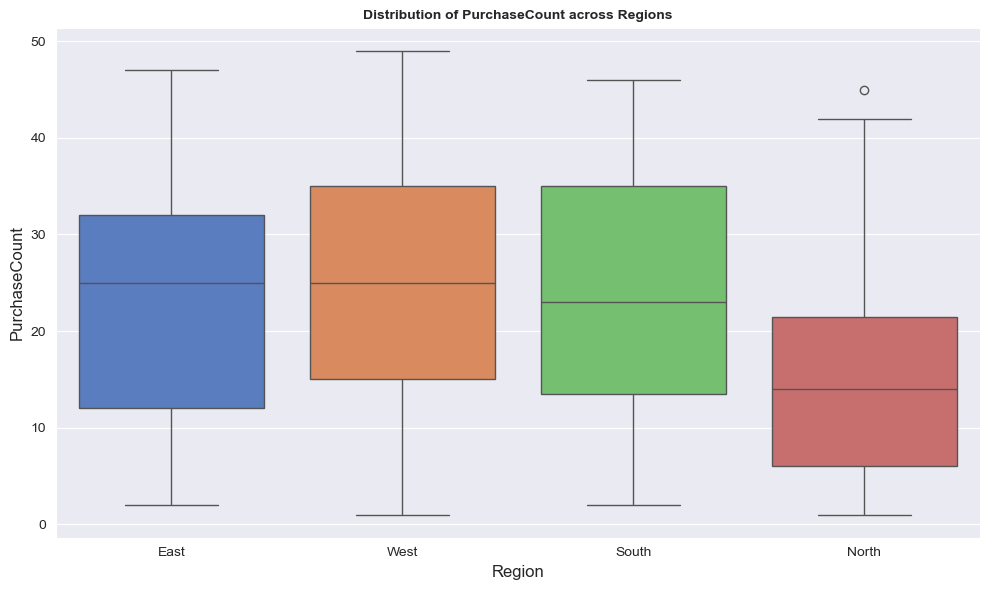

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Region',y='PurchaseCount',hue='Region',palette='muted')
plt.xlabel('Region',fontsize=12)
plt.ylabel('PurchaseCount',fontsize=12)
plt.title('Distribution of PurchaseCount across Regions',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.5: Heatmap
#### Create a heatmap showing correlations between numeric columns.

In [26]:
numeric_cols=df[['CustomerID','Age','Income','PurchaseCount','AvgOrderValue','CustomerRating','YearsAsCustomer']]
correlation=numeric_cols.corr()

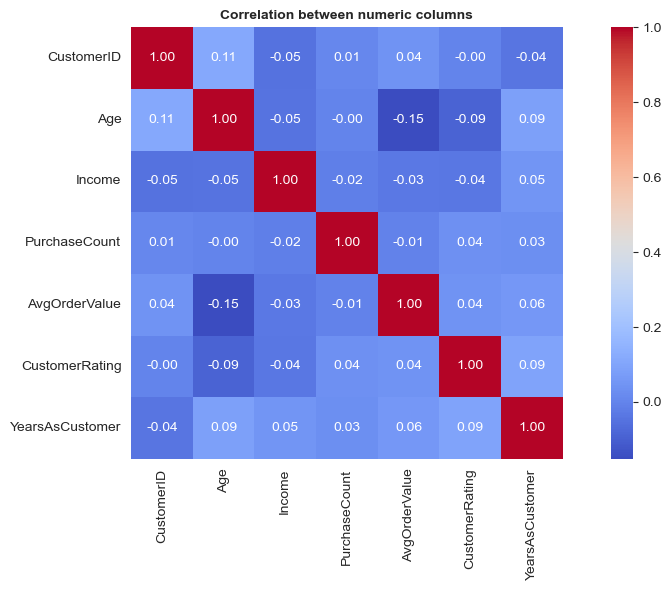

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cbar=True,square=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation between numeric columns',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.6: Bar Plot with CI
#### Create a bar plot showing average CustomerRating by Category with confidence intervals

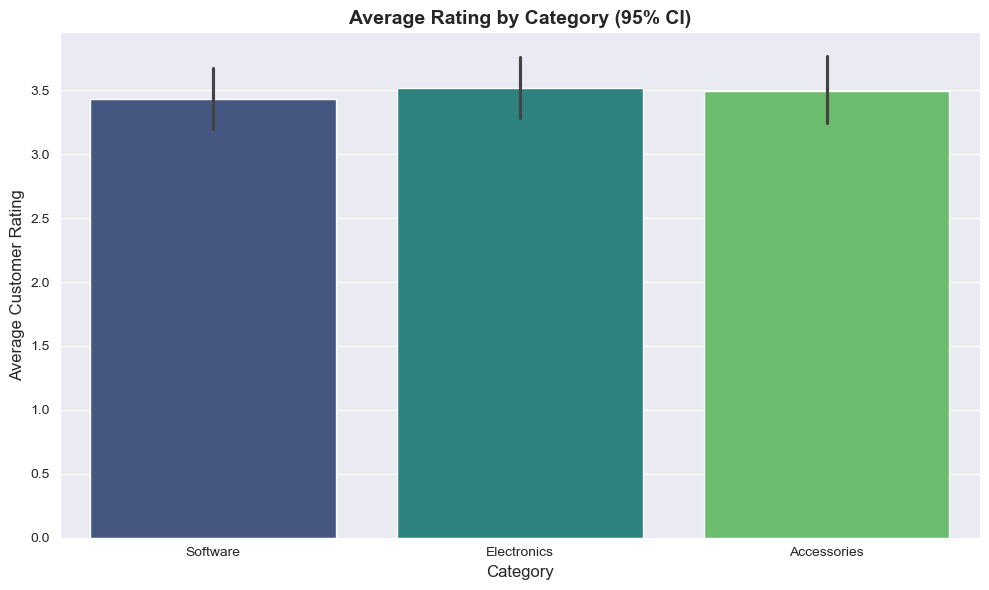

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Category', y='CustomerRating', palette='viridis',hue='Category')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Customer Rating', fontsize=12)
plt.title('Average Rating by Category (95% CI)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.7: Pair Plot
#### Create a pair plot for Age, Income, PurchaseCount, CustomerRating colored by Region

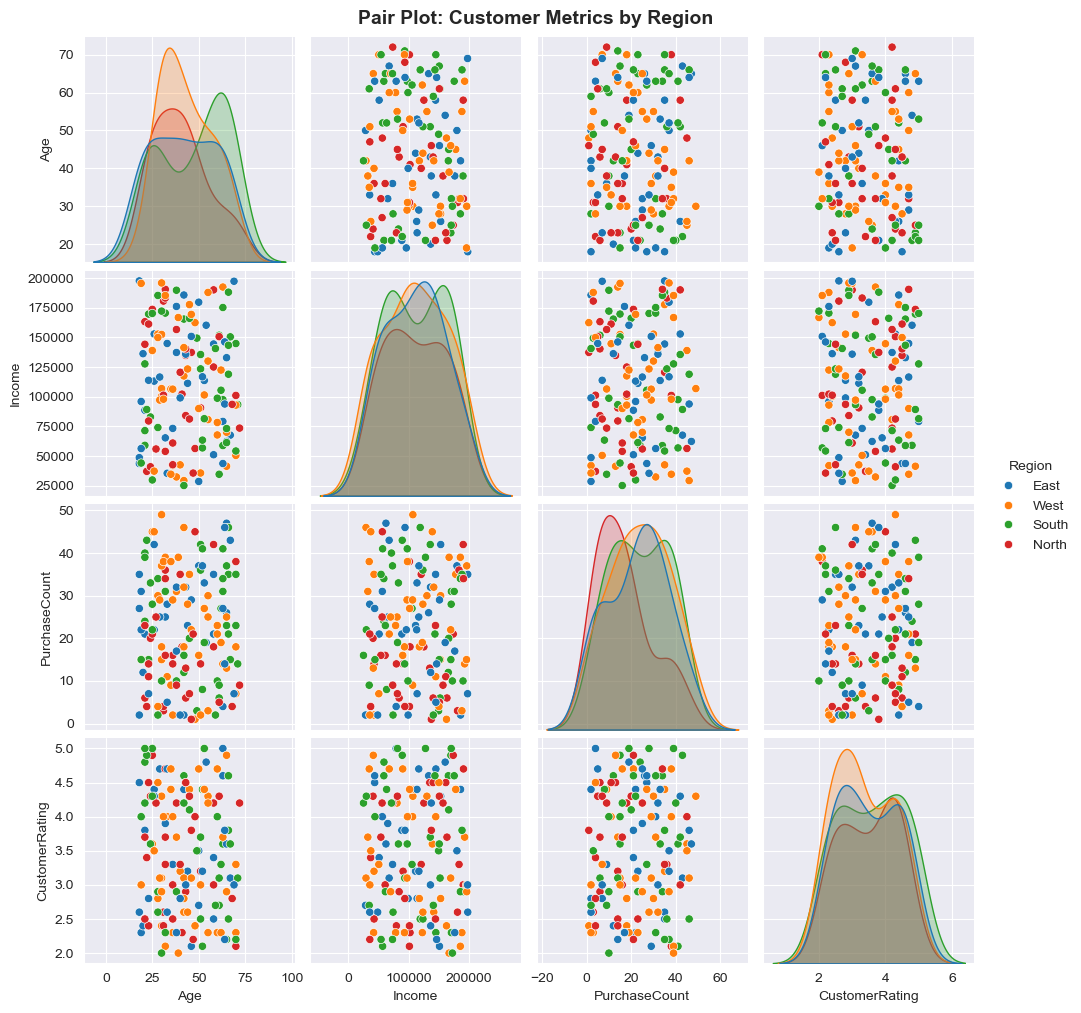

In [18]:
sns.pairplot(data=df,
             vars=['Age','Income','PurchaseCount','CustomerRating'],
             hue='Region',
             diag_kind='kde')
plt.suptitle('Pair Plot: Customer Metrics by Region', y=1.01, fontsize=14, fontweight='bold')
plt.show()

## Q6.8: Violin Plot
#### Create a violin plot showing the distribution of AvgOrderValue by Region

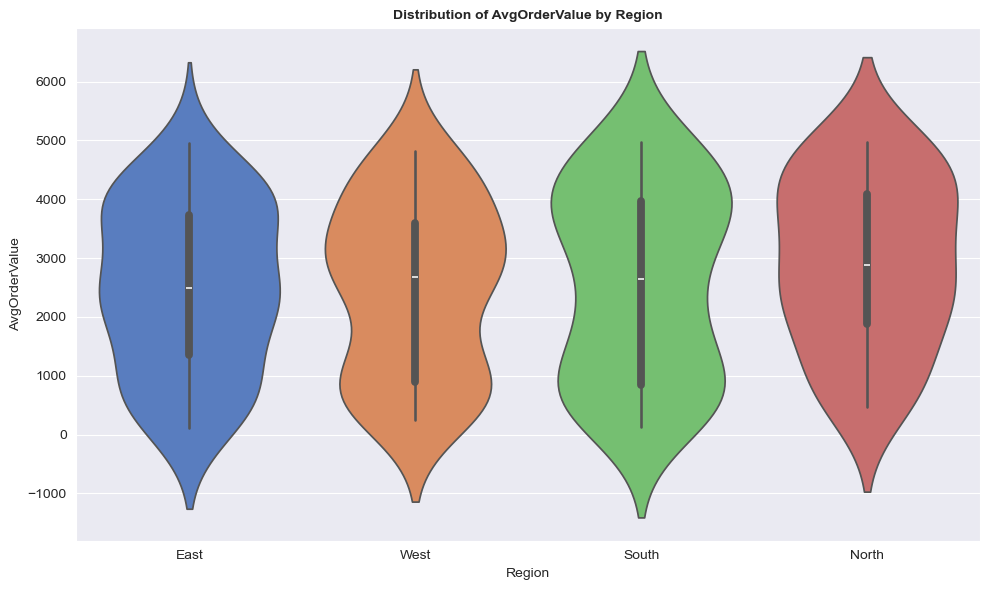

In [24]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df,x='Region',y='AvgOrderValue',palette='muted',hue='Region')
plt.xlabel('Region')
plt.ylabel('AvgOrderValue')
plt.title('Distribution of AvgOrderValue by Region',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.9: Clustermap
#### Create a clustermap (hierarchical heatmap) of customer metrics.

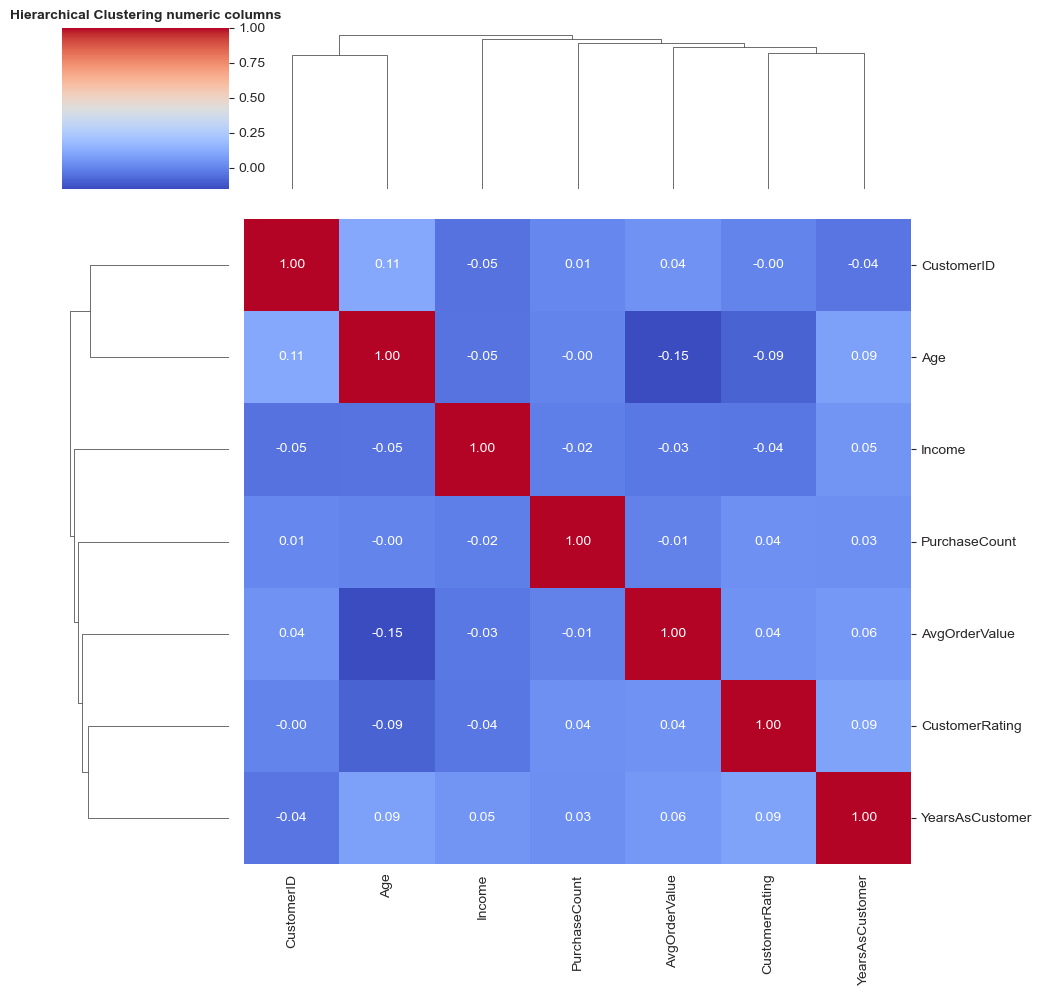

In [30]:
sns.clustermap(correlation,annot=True,cbar=True,fmt='.2f',cmap='coolwarm')
plt.title('Hierarchical Clustering numeric columns',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

## Q6.10: Joint Plot
#### Create a joint plot showing Age vs CustomerRating relationship with marginal distributions

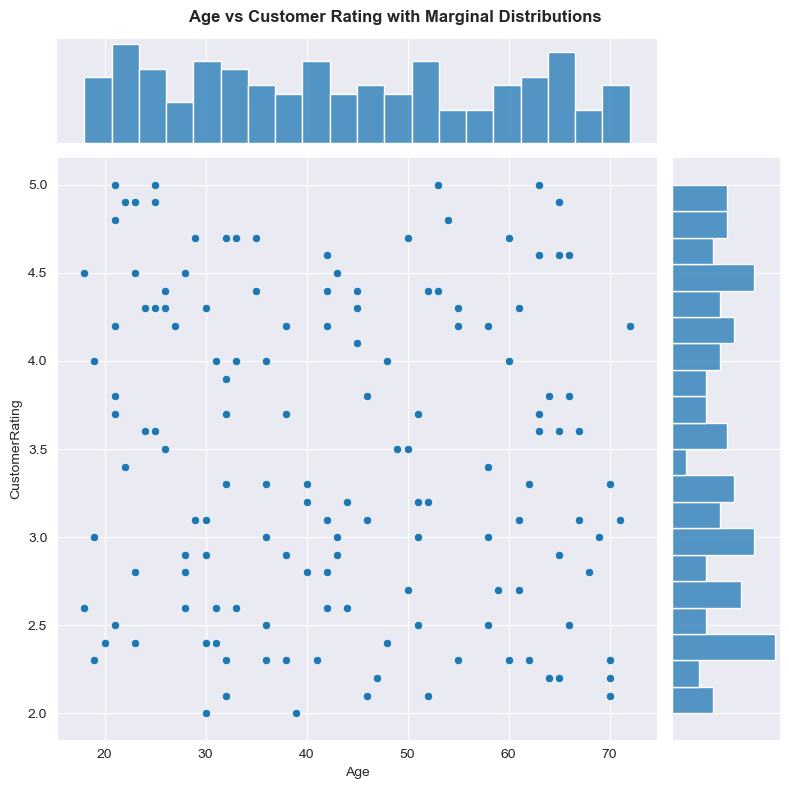

In [32]:
sns.jointplot(data=df, x='Age', y='CustomerRating', kind='scatter', 
height=8, space=0.2, marginal_kws=dict(bins=20))
plt.suptitle('Age vs Customer Rating with Marginal Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Challenge Extension.

#### Challenge 1: Create a custom color palette and apply to multiple plots.

In [46]:
custom_palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']
sns.set_palette(custom_palette)

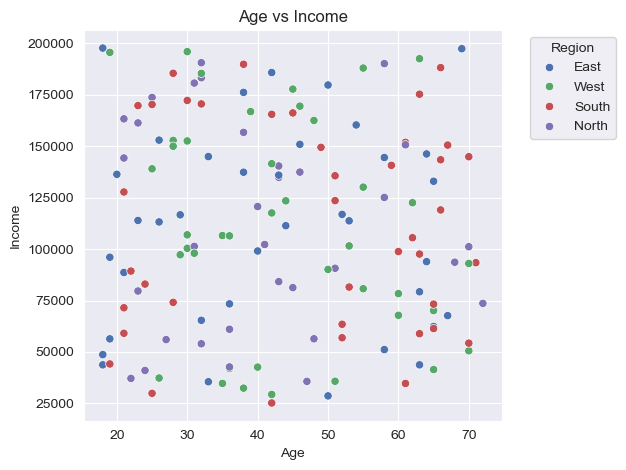

In [48]:
sns.scatterplot(data=df, x='Age', y='Income', hue='Region')
plt.title('Age vs Income')
plt.legend(loc='upper left',fontsize=10,title='Region',bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

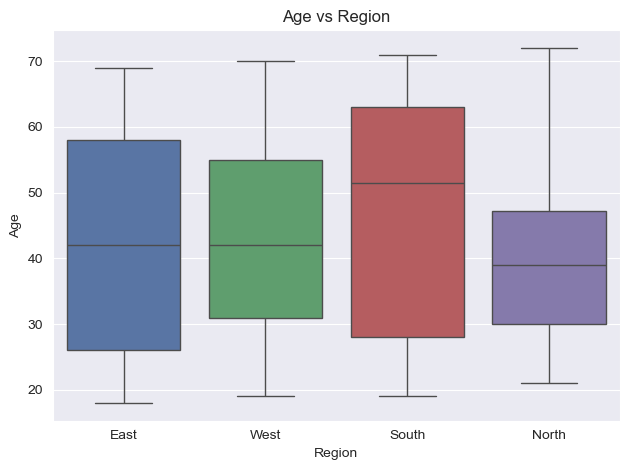

In [58]:
sns.boxplot(data=df, x='Region', y='Age', hue='Region')
plt.title('Age vs Region')
plt.tight_layout()
plt.show()

#### Challenge 2: Use FacetGrid for complex multi-variable analysis.

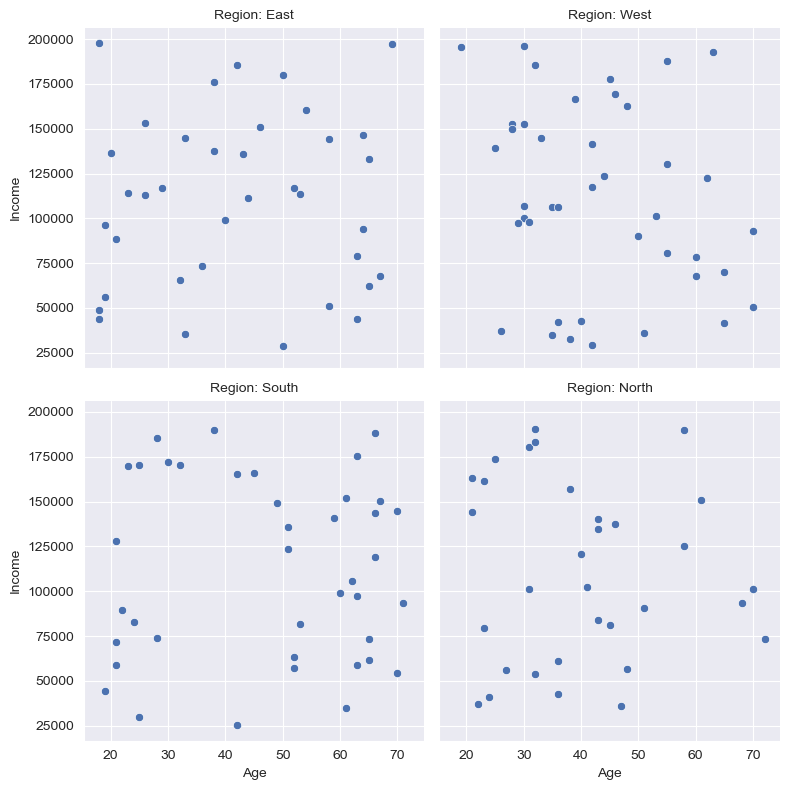

In [59]:
g = sns.FacetGrid(data=df, col="Region", col_wrap=2, height=4, aspect=1)
g.map_dataframe(sns.scatterplot, x="Age", y="Income")
g.set_axis_labels("Age", "Income")
g.set_titles("Region: {col_name}")
plt.show()

#### Challenge 3: Create regression plots with confidence bands

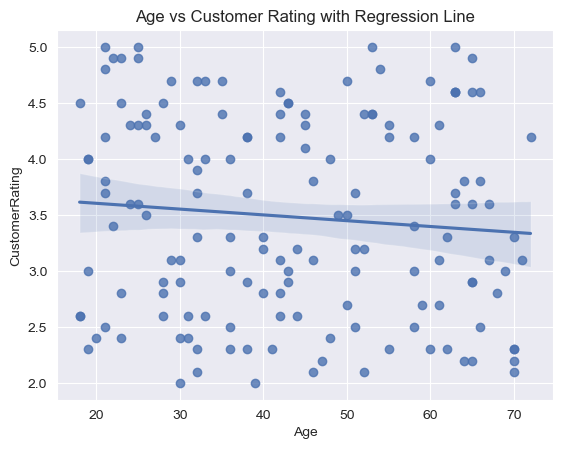

In [60]:
sns.regplot(data=df, x='Age', y='CustomerRating')
plt.title('Age vs Customer Rating with Regression Line')
plt.xlabel('Age')
plt.ylabel('CustomerRating')
plt.show()